In [ ]:
# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df = pd.read_csv('/content/lowongan data dan analytics jobstreet.csv')
df.head(10)

,posisi,perusahaan,kota,provinsi,gaji,tools,pendidikan,pengalaman,deskripsi_lengkap,level
0,Data Analyst,PT IEKIMTIE MEDIKA WEST,Genteng,Jawa Timur,NaN,SQL,"Industrial Engineering, Informatics Engineering",0.0,Kualifikasi\n:\nS1 Teknik Industri / Informati...,Entry Level
1,Data Analyst/Intelligence,PT Susu Life Indonesia,Jakarta Barat,Jakarta Raya,NaN,"Power BI, Tableau, Excel","Accounting, Economics, Finance",3.0,"Key Responsibilities\nBuild, maintain, and aut...",Mid Level
2,DATA ANALYST,PT Venindo Jaya Abadi,Jakarta Utara,Jakarta Raya,9500000.0,"SPSS, SQL, Python, Power BI, Oracle, Excel",NaN,NaN,Job Desk Data Analyst\nBerikut merupakan Job D...,NaN
3,Data Analyst Associate,PT Solusi Transportasi Indonesia,Jakarta Lainnya,Jakarta Raya,NaN,"SQL, Tableau, Python, Power BI, Oracle","Business Analytics, Computer Science, Data Ana...",5.0,Company Description\nAbout Grab and Our Workpl...,Senior Level
4,Data Analyst Officer for Finance Divison,PT Global Jet Express (Cabang Jakarta),Jakarta Utara,Jakarta Raya,NaN,Excel,NaN,3.0,Responsibilities:\nSupporting Accounting Divis...,Mid Level
5,Data Analyst,PT Citarasa Kuliner Indonesia (Cimol Bojot AA),Bandung,Jawa Barat,8000000.0,"SQL, Tableau, Metabase, Google Data Studio, Py...",NaN,2.0,Cimol Bojot AA (PT Citarasa Kuliner Indonesia)...,Mid Level
6,Data Analyst Staff,PT Chateraise Gobel Indonesia,Jakarta Lainnya,Jakarta Raya,NaN,"SQL, Excel, Python","Business Administration, Marketing",2.0,"Job Description :\nCollect, organize and analy...",Mid Level
7,Data Analyst Staff,PT Sukanda Djaya,Bekasi,Jawa Barat,NaN,"SQL, Excel","Information Technology, Mathematics, Statistics",2.0,"Tanggung Jawab Utama :\nMengumpulkan, memprose...",Mid Level
8,DATA ANALYST,PT ORIENTAMA MAKMUR ABADI,Jakarta Lainnya,Jakarta Raya,10000000.0,"API, SQL, Tableau, Looker, Python, Power BI, E...","Computer Science, Data Science, Management",NaN,"As Data Analyst, you will directly\nreport to ...",NaN
9,MARKETING DATA ANALYST,PT Yamaha Indonesia Motor Mfg,Jakarta Timur,Jakarta Raya,NaN,"SQL, Adobe Analytics, Python, R, Power BI, Excel","Communication, Computer Science, Data Science,...",1.0,"Requirement :\nS1 Data Science / data analis, ...",Entry Level


In [ ]:
# ============================================================
# 1. CLEANSING DATA
# ============================================================

def to_snake(s):
    return re.sub(r'[^a-z0-9]+', '_', str(s).strip().lower()).strip('_')

df.columns = [to_snake(c) for c in df.columns]
print("Columns:", df.columns.tolist())

def clean_text(x):
    if pd.isna(x):
        return ""
    return re.sub(r'\s+', ' ', str(x)).strip()

text_cols = [
    "posisi", "perusahaan", "kota", "provinsi",
    "tools", "pendidikan", "deskripsi_lengkap", "level"
]
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].map(clean_text)


Columns: ['posisi', 'perusahaan', 'kota', 'provinsi', 'gaji', 'tools', 'pendidikan', 'pengalaman', 'deskripsi_lengkap', 'level']


In [ ]:
# ============================================================
# 2. BUILD CANONICAL JOB DATAFRAME (final_df)
# ============================================================
canon = pd.DataFrame()
canon["job_id"] = np.arange(1, len(df) + 1)

canon["title"] = df.get("posisi", "")
canon["company"] = df.get("perusahaan", "")
canon["location"] = np.where(
    df.get("kota", "") == "",
    df.get("provinsi", ""),
    df.get("kota", "")
)
canon["industry"] = ""
canon["job_function"] = ""
canon["employment_type"] = ""
canon["experience_level"] = df.get("level", "")
canon["education"] = df.get("pendidikan", "")

canon["salary_text"] = df.get("gaji", "").astype(str)
canon["description"] = df.get("deskripsi_lengkap", "")
canon["benefits"] = ""
canon["date_posted"] = ""   # bisa diisi kalau datanya ada
canon["source"] = "Jobstreet"
canon["url"] = ""


In [ ]:

# ============================================================
# 3. PARSE SALARY → IDR PER MONTH (TARGET = salary_mid_month_idr)
# ============================================================
MONTH_HOURS = 173
MONTH_DAYS = 22

def parse_salary_row(s):
    if s is None or (isinstance(s, float) and np.isnan(s)) or str(s).strip() == "":
        return np.nan, np.nan, "IDR", "monthly", False

    st = str(s).lower().strip()

    # angka polos → anggap sudah monthly IDR
    if re.fullmatch(r'\d+(\.\d+)?', st):
        v = float(st)
        return v, v, "IDR", "monthly", True

    currency = "IDR" if ("rp" in st or "idr" in st or "rupiah" in st) else "IDR"

    period = None
    if any(p in st for p in ["per month", "per bulan", "/bulan", "bulan"]):
        period = "monthly"
    elif any(p in st for p in ["per year", "per tahun", "/tahun", "tahun", "annum", "yearly"]):
        period = "yearly"
    elif any(p in st for p in ["per day", "/hari", "hari", "daily"]):
        period = "daily"
    elif any(p in st for p in ["per hour", "/jam", "hourly", "jam"]):
        period = "hourly"

    nums = re.findall(r'[\d\.,]+', st)

    def to_num(x):
        xs = x.replace(".", "").replace(",", "")
        try:
            return float(xs)
        except:
            return np.nan

    vals = [to_num(x) for x in nums if not np.isnan(to_num(x))]
    if not vals:
        return np.nan, np.nan, currency, period or "monthly", False

    if len(vals) >= 2:
        vmin, vmax = min(vals[0], vals[1]), max(vals[0], vals[1])
    else:
        vmin = vmax = vals[0]

    # normalisasi ke bulanan
    if period == "yearly":
        vmin, vmax = vmin / 12.0, vmax / 12.0
        period = "monthly"
    elif period == "daily":
        vmin, vmax = vmin * MONTH_DAYS, vmax * MONTH_DAYS
        period = "monthly"
    elif period == "hourly":
        vmin, vmax = vmin * MONTH_HOURS, vmax * MONTH_HOURS
        period = "monthly"
    else:
        period = "monthly"

    return vmin, vmax, currency, period, True

parsed = canon["salary_text"].apply(parse_salary_row)
canon["salary_min_month_idr"] = parsed.apply(lambda x: x[0])
canon["salary_max_month_idr"] = parsed.apply(lambda x: x[1])
canon["salary_currency"] = parsed.apply(lambda x: x[2])
canon["salary_period"] = parsed.apply(lambda x: x[3])
canon["salary_disclosed"] = parsed.apply(lambda x: x[4])
canon["salary_mid_month_idr"] = canon[["salary_min_month_idr", "salary_max_month_idr"]].mean(axis=1)

print("Sample parsed salaries:")
print(canon[["salary_text", "salary_min_month_idr", "salary_max_month_idr", "salary_mid_month_idr"]].head())


Sample parsed salaries:
  salary_text  salary_min_month_idr  salary_max_month_idr  \
0         nan                   NaN                   NaN   
1         nan                   NaN                   NaN   
2   9500000.0             9500000.0             9500000.0   
3         nan                   NaN                   NaN   
4         nan                   NaN                   NaN   

   salary_mid_month_idr  
0                   NaN  
1                   NaN  
2             9500000.0  
3                   NaN  
4                   NaN  


In [ ]:
# ============================================================
# 4. TEXT-MINED SKILLS & BASIC TEXT FEATURES
# ============================================================
skills = [
    "python","r","sql","excel","power bi","tableau","looker","google data studio","superset",
    "machine learning","ml","statistics","statistical","regression","classification","clustering",
    "deep learning","nlp","natural language","tensorflow","pytorch","sklearn","scikit-learn",
    "spark","hadoop","big data","databricks","snowflake","redshift","bigquery","postgres","mysql",
    "aws","azure","gcp","airflow","dbt","kafka","git","docker","kubernetes",
    "communication","leadership","bahasa indonesia","english","etl","data warehouse","data lake"
]

def sname(s):
    return re.sub(r'[^a-z0-9]+', '_', s.lower()).strip('_')

tools_text = df["tools"].fillna("") if "tools" in df.columns else ""

text_all_for_skills = (
    canon["title"].fillna("") + " " +
    canon["description"].fillna("") + " " +
    tools_text
).str.lower()

for sk in skills:
    canon[f"skill_{sname(sk)}"] = text_all_for_skills.str.contains(
        rf"\b{re.escape(sk)}\b", regex=True, na=False
    ).astype(int)

skill_cols = [c for c in canon.columns if c.startswith("skill_")]
canon["skill_count"] = canon[skill_cols].sum(axis=1)
canon["desc_word_count"] = canon["description"].fillna("").str.findall(r'\w+').str.len()
canon["desc_char_count"] = canon["description"].fillna("").str.len()


In [ ]:
# ============================================================
# 5. EXPERIENCE, SENIORITY, REMOTE FLAG
# ============================================================
canon["experience_years"] = pd.to_numeric(df.get("pengalaman", np.nan), errors="coerce")

def extract_years(text):
    if not isinstance(text, str):
        return np.nan
    m = re.findall(r'(\d+)\s*(?:\+|-\d+)?\s*(?:year|years|yr|yrs|tahun|thn)', text.lower())
    if not m:
        return np.nan
    try:
        return max(int(x) for x in m)
    except:
        return np.nan

canon["experience_years"] = canon["experience_years"].fillna(
    canon["description"].apply(extract_years)
)

seniority_terms = {
    "intern": r"\bmagang\b|\bintern(ship)?\b",
    "junior": r"\bjunior\b|\bjr\b",
    "middle": r"\bmid(dle)?\b|\bintermediate\b|\bassociate\b",
    "senior": r"\bsenior\b|\bsr\b",
    "lead": r"\blead\b|\bleadership\b",
    "manager": r"\bmanager\b|\bmanajer\b|\bhead\b|\bdirector\b|\bprincipal\b"
}

def infer_seniority(row):
    if isinstance(row.get("experience_level"), str) and row.get("experience_level").strip() != "":
        return row.get("experience_level")
    t = f"{row.get('title','')} {row.get('description','')}".lower()
    for level, pat in seniority_terms.items():
        if re.search(pat, t):
            return level
    return ""

canon["experience_level"] = canon["experience_level"].replace("", np.nan)
canon["seniority_inferred"] = canon.apply(infer_seniority, axis=1)

canon["remote_flag"] = text_all_for_skills.str.contains(
    r"\bremote\b|\bhybrid\b|\bwork from home\b|\bwfh\b",
    regex=True, na=False
).astype(int)


In [ ]:
# ============================================================
# 6. DEDUPLICATION & FINAL_DF
# ============================================================
key_series = (
    canon["title"].str.lower().fillna("") + " | " +
    canon["company"].str.lower().fillna("") + " | " +
    canon["location"].str.lower().fillna("") + " | " +
    canon["description"].str.lower().fillna("")
)

canon["dup_hash"] = pd.util.hash_pandas_object(key_series, index=False).astype(str)
canon = canon.drop_duplicates(subset=["dup_hash"]).copy()

order = [
    "job_id", "title", "company", "location", "industry", "job_function", "employment_type",
    "experience_level", "education", "seniority_inferred", "experience_years",
    "salary_text", "salary_currency", "salary_min_month_idr", "salary_max_month_idr",
    "salary_mid_month_idr", "salary_period", "salary_disclosed",
    "desc_word_count", "desc_char_count", "skill_count", "remote_flag",
] + skill_cols + [
    "benefits", "description", "date_posted", "source", "url", "dup_hash"
]
order = [c for c in order if c in canon.columns]
final_df = canon[order].copy()

final_csv = "/content/indonesia_jobstreet_data_analytics_clean.csv"
final_xlsx = "/content/indonesia_jobstreet_data_analytics_clean.xlsx"
final_df.to_csv(final_csv, index=False, encoding="utf-8-sig")
final_df.to_excel(final_xlsx, index=False)

print("Saved cleaned dataset:", final_csv, final_xlsx)
print("Final shape:", final_df.shape)

Saved cleaned dataset: /content/indonesia_jobstreet_data_analytics_clean.csv /content/indonesia_jobstreet_data_analytics_clean.xlsx
Final shape: (555, 76)


In [ ]:
# ============================================================
# 7. SUBSET UNTUK MODEL: HANYA YANG PUNYA GAJI
# ============================================================
target_col = "salary_mid_month_idr"
data = final_df[final_df[target_col].notna()].copy()

print("Total rows (all):", len(final_df))
print("Rows with salary:", len(data))
print("Salary disclosure rate:", data.shape[0] / final_df.shape[0])


Total rows (all): 555
Rows with salary: 77
Salary disclosure rate: 0.13873873873873874


In [ ]:

# ============================================================
# 8. CLEAN TEXT (ID + EN) UNTUK TEXT MINING (HANYA KATA RELEVAN)
# ============================================================
# Tambah / perketat stopword & kata generik
stopwords_id = {
    "dan","atau","yang","dengan","serta","untuk","dalam","pada","di","ke","dari",
    "kami","kita","anda","kamu","mereka","sebagai","adalah","ialah","itu","ini",
    "agar","juga","oleh","dapat","akan","telah","sudah","sedang","bagi","para",
    "tentang","dll","dsb","karena","sehingga","jadi","atas","hingga"
}

stopwords_en = {
    "and","or","the","a","an","to","of","in","on","at","for","from","as","is","are",
    "was","were","be","been","being","by","with","that","this","these","those",
    "we","you","they","our","your","their","about","us","will","can","may","must",
    "should","etc","such","per","into","within"
}

# kata/frasa generik lowongan yang tidak ingin dianggap determinant
job_generic_words = {
    "company","perusahaan","team","tim","environment","culture","values",
    "vision","mission","visi","misi","career","karir","karier",
    "responsibilities","responsibility","tanggung","jawab","requirement",
    "requirements","kualifikasi","qualification","qualifications",
    "job","role","position","posisi","lowongan","vacancy","apply","lamar",
    "application","pelamar","candidate","candidates",
    "staff","fulltime","full","time","parttime","part","contract","internship",
    "magang","profile","profil","alur","kerja","deskripsi",
    "bergabung","join","joining","bagian","penting","menjadi",
    "accelerates","accelerate","across","alongside"
}

def clean_for_text_mining(text):
    if not isinstance(text, str):
        return ""
    t = text.lower()

    # opsional: hapus beberapa frasa marketing dulu
    phrase_stop = [
        "bergabung bersama kami",
        "bagian penting",
        "part of our team",
        "join our team",
        "menjadi bagian"
    ]
    for ph in phrase_stop:
        t = t.replace(ph, " ")

    # buang karakter non-huruf
    t = re.sub(r'[^a-zA-Z]', ' ', t)
    tokens = t.split()

    filtered = []
    for tok in tokens:
        if len(tok) <= 2:
            continue
        if tok in stopwords_en or tok in stopwords_id:
            continue
        if tok in job_generic_words:
            continue
        filtered.append(tok)

    return " ".join(filtered)

# pakai fungsi baru ini
data["text_all"] = (
    data["title"].fillna("") + " " +
    data["description"].fillna("")
).apply(clean_for_text_mining)


In [ ]:
# ============================================================
# 9. FEATURE SET: NUMERIC, CATEGORICAL, TEXT (FINAL)
# ============================================================
skill_cols_model = [c for c in data.columns if c.startswith("skill_") and c != "skill_count"]
num_feats = ["experience_years", "desc_word_count", "desc_char_count", "skill_count"] + skill_cols_model
cat_feats = ["seniority_inferred", "experience_level", "location"]

for c in num_feats:
    if c not in data.columns:
        data[c] = 0
for c in cat_feats:
    if c not in data.columns:
        data[c] = "missing"

feature_cols = ["text_all"] + num_feats + cat_feats

X = data[feature_cols].copy()
y = data[target_col].astype(float)

# Hilangkan nama kolom duplikat
X = X.loc[:, ~X.columns.duplicated()]

# Impute final: tidak boleh ada NaN
for c in num_feats:
    if c in X.columns:
        X[c] = X[c].fillna(0)
for c in cat_feats:
    if c in X.columns:
        X[c] = X[c].fillna("missing")
X["text_all"] = X["text_all"].fillna("")

print("Total features:", len(X.columns))

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, "| Valid shape:", X_valid.shape)

text_col = "text_all"

Total features: 56
Train shape: (61, 56) | Valid shape: (16, 56)


In [ ]:
# ============================================================
# 10. RIDGE REGRESSION – FROM WORDS TO WAGES
# ============================================================
ridge_preprocess = ColumnTransformer(
    transformers=[
        ("txt", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9
        ), text_col),
        ("num", StandardScaler(with_mean=False),
         [c for c in num_feats if c in X_train.columns]),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         [c for c in cat_feats if c in X_train.columns]),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

ridge_model = Pipeline(steps=[
    ("prep", ridge_preprocess),
    ("mdl", Ridge(alpha=5.0, random_state=42))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_valid)

ridge_mae = mean_absolute_error(y_valid, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_valid, ridge_pred))
ridge_r2 = r2_score(y_valid, ridge_pred)

print("\n=== Ridge model (with text) ===")
print(f"MAE  : {ridge_mae:,.0f} IDR")
print(f"RMSE : {ridge_rmse:,.0f} IDR")
print(f"R²   : {ridge_r2:.3f}")


=== Ridge model (with text) ===
MAE  : 3,381,503 IDR
RMSE : 4,032,661 IDR
R²   : 0.216


In [ ]:
# ============================================================
# 11. LASSO REGRESSION – SPARSE DETERMINANTS
# ============================================================
lasso_preprocess = ColumnTransformer(
    transformers=[
        ("txt", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9
        ), text_col),
        ("num", StandardScaler(with_mean=False),
         [c for c in num_feats if c in X_train.columns]),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         [c for c in cat_feats if c in X_train.columns]),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

lasso_model = Pipeline(steps=[
    ("prep", lasso_preprocess),
    ("mdl", Lasso(alpha=0.001, max_iter=10000, random_state=42))
])

lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_valid)

lasso_mae = mean_absolute_error(y_valid, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_valid, lasso_pred))
lasso_r2 = r2_score(y_valid, lasso_pred)

print("\n=== Lasso model (with text) ===")
print(f"MAE  : {lasso_mae:,.0f} IDR")
print(f"RMSE : {lasso_rmse:,.0f} IDR")
print(f"R²   : {lasso_r2:.3f}")



=== Lasso model (with text) ===
MAE  : 3,492,841 IDR
RMSE : 4,229,941 IDR
R²   : 0.137


In [ ]:
# ============================================================
# 12. BASELINE: TANPA TEKS (NUMERIC + CATEGORICAL SAJA)
# ============================================================
X_base = data[num_feats + cat_feats].copy()
X_base = X_base.loc[:, ~X_base.columns.duplicated()]

for c in num_feats:
    if c in X_base.columns:
        X_base[c] = X_base[c].fillna(0)
for c in cat_feats:
    if c in X_base.columns:
        X_base[c] = X_base[c].fillna("missing")

Xb_train, Xb_valid, yb_train, yb_valid = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

num_feats_base = [c for c in num_feats if c in Xb_train.columns]
cat_feats_base = [c for c in cat_feats if c in Xb_train.columns]

base_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_feats_base),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats_base),
    ],
    remainder="drop"
)

base_model = Pipeline(steps=[
    ("prep", base_preprocess),
    ("mdl", LinearRegression())
])

base_model.fit(Xb_train, yb_train)
base_pred = base_model.predict(Xb_valid)

base_mae = mean_absolute_error(yb_valid, base_pred)
base_rmse = np.sqrt(mean_squared_error(yb_valid, base_pred))
base_r2 = r2_score(yb_valid, base_pred)

print("\n=== Baseline model (no text) ===")
print(f"MAE  : {base_mae:,.0f} IDR")
print(f"RMSE : {base_rmse:,.0f} IDR")
print(f"R²   : {base_r2:.3f}")

print("\n=== Summary: Baseline vs Ridge vs Lasso ===")
print(f"Baseline | MAE: {base_mae:,.0f} | RMSE: {base_rmse:,.0f} | R²: {base_r2:.3f}")
print(f"Ridge    | MAE: {ridge_mae:,.0f} | RMSE: {ridge_rmse:,.0f} | R²: {ridge_r2:.3f}")
print(f"Lasso    | MAE: {lasso_mae:,.0f} | RMSE: {lasso_rmse:,.0f} | R²: {lasso_r2:.3f}")



=== Baseline model (no text) ===
MAE  : 4,167,285 IDR
RMSE : 4,899,759 IDR
R²   : -0.158

=== Summary: Baseline vs Ridge vs Lasso ===
Baseline | MAE: 4,167,285 | RMSE: 4,899,759 | R²: -0.158
Ridge    | MAE: 3,381,503 | RMSE: 4,032,661 | R²: 0.216
Lasso    | MAE: 3,492,841 | RMSE: 4,229,941 | R²: 0.137



=== 5-fold CV R² ===
Baseline: -0.6591821997488014 +/- 0.7631573862860749
Ridge   : 0.06884231004703252 +/- 0.37213388016868854
Lasso   : -0.700206103090677 +/- 0.4770860277038479


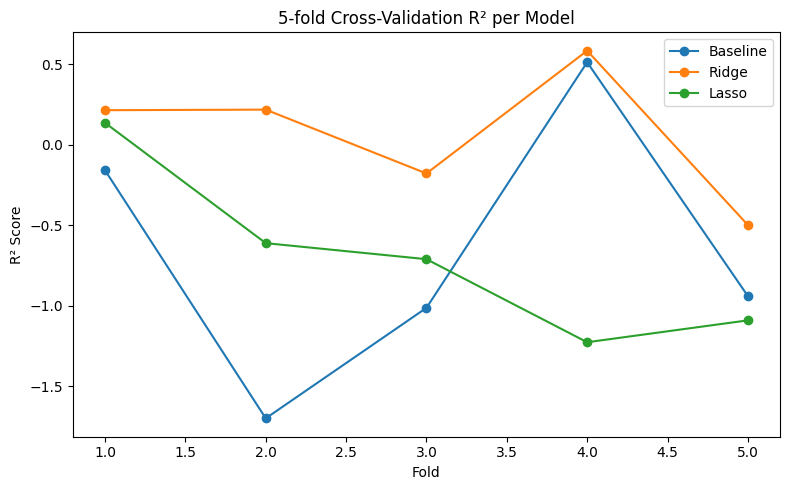

In [ ]:
# ============================================================
# 13. K-FOLD CROSS VALIDATION (R²) – MODEL COMPARISON
# ============================================================
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_r2(model, X_input, y_input):
    scores = cross_val_score(model, X_input, y_input,
                             cv=kfold, scoring="r2", n_jobs=-1)
    return scores

ridge_cv = cv_r2(ridge_model, X, y)
lasso_cv = cv_r2(lasso_model, X, y)
base_cv  = cv_r2(base_model,  X_base, y)

print("\n=== 5-fold CV R² ===")
print("Baseline:", base_cv.mean(), "+/-", base_cv.std())
print("Ridge   :", ridge_cv.mean(), "+/-", ridge_cv.std())
print("Lasso   :", lasso_cv.mean(), "+/-", lasso_cv.std())

folds = np.arange(1, len(ridge_cv) + 1)

plt.figure(figsize=(8, 5))
plt.plot(folds, base_cv, marker="o", label="Baseline")
plt.plot(folds, ridge_cv, marker="o", label="Ridge")
plt.plot(folds, lasso_cv, marker="o", label="Lasso")
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("5-fold Cross-Validation R² per Model")
plt.legend()
plt.tight_layout()
plt.show()


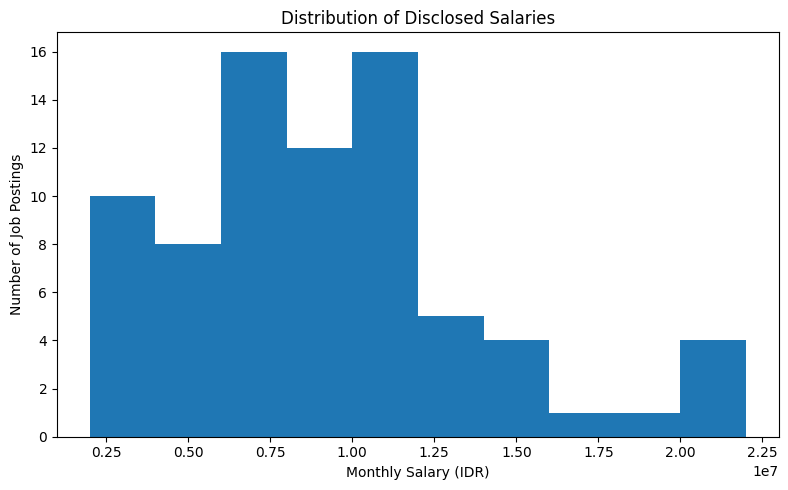

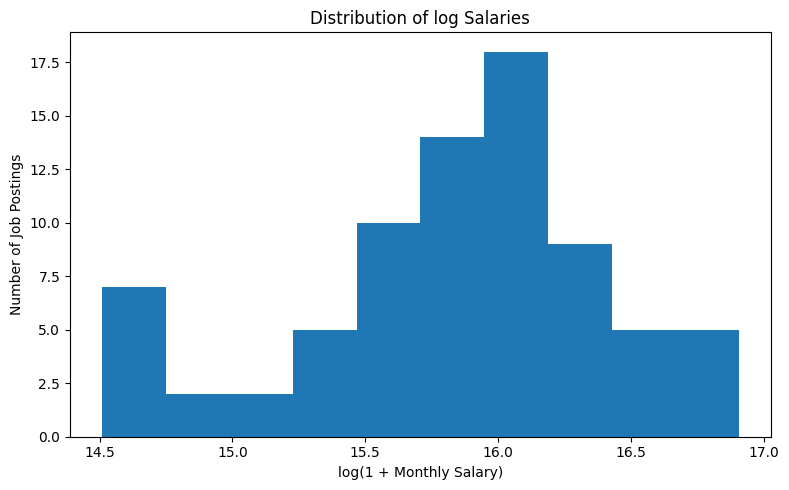

In [ ]:
# ============================================================
# 14. SALARY DISTRIBUTION VISUALIZATION
# ============================================================
salary_series = data["salary_mid_month_idr"]

plt.figure(figsize=(8, 5))
plt.hist(salary_series, bins=10)
plt.xlabel("Monthly Salary (IDR)")
plt.ylabel("Number of Job Postings")
plt.title("Distribution of Disclosed Salaries")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(salary_series), bins=10)
plt.xlabel("log(1 + Monthly Salary)")
plt.ylabel("Number of Job Postings")
plt.title("Distribution of log Salaries")
plt.tight_layout()
plt.show()


/tmp/ipython-input-1898034151.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showmeans=True)


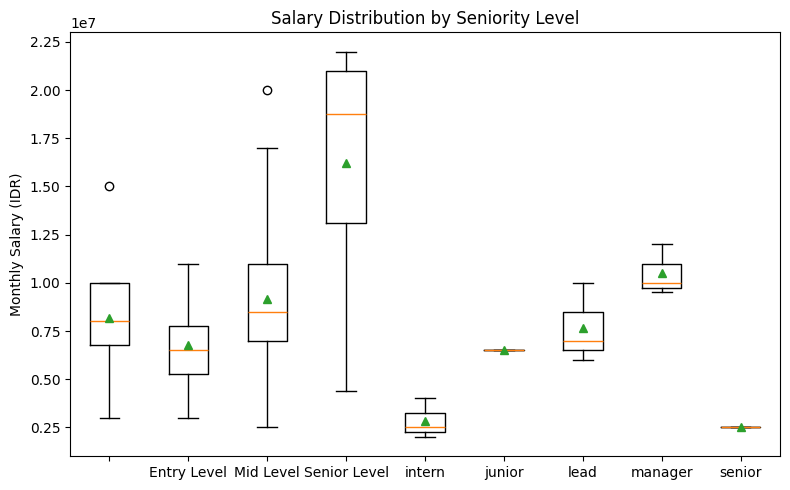

In [ ]:
# ============================================================
# 15. SALARY BY SENIORITY (BOXPLOT)
# ============================================================
tmp = data.copy()
tmp["seniority_plot"] = tmp["seniority_inferred"].fillna("Unknown")

groups = []
labels = []
for name, g in tmp.groupby("seniority_plot"):
    if g["salary_mid_month_idr"].notna().sum() == 0:
        continue
    labels.append(name)
    groups.append(g["salary_mid_month_idr"].values)

plt.figure(figsize=(8, 5))
plt.boxplot(groups, labels=labels, showmeans=True)
plt.ylabel("Monthly Salary (IDR)")
plt.title("Salary Distribution by Seniority Level")
plt.tight_layout()
plt.show()


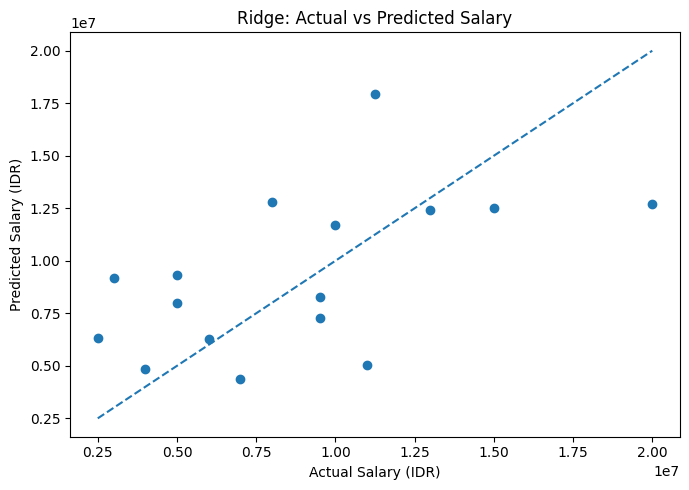

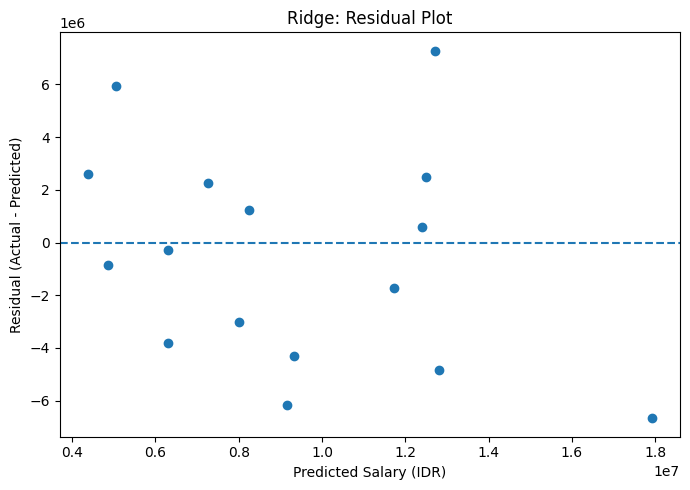

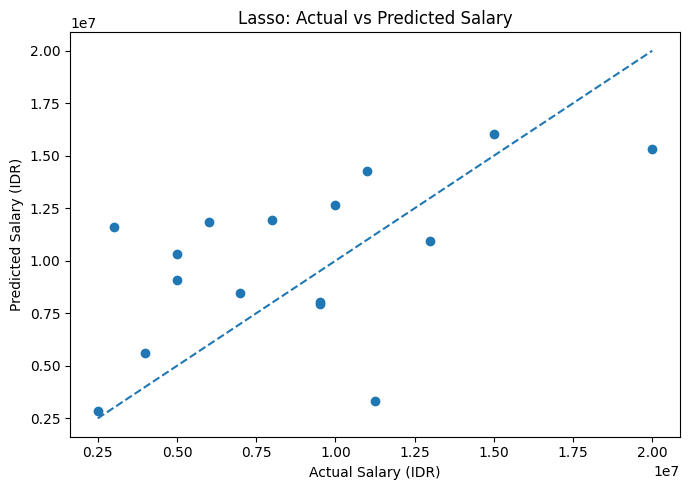

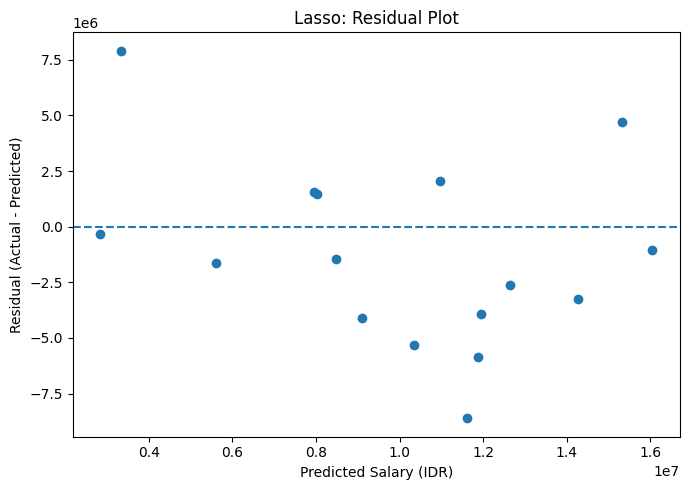

In [ ]:
# ============================================================
# 16. ACTUAL vs PREDICTED & RESIDUAL PLOTS (RIDGE & LASSO)
# ============================================================
# Ridge
y_true = y_valid

plt.figure(figsize=(7, 5))
plt.scatter(y_true, ridge_pred)
min_val = min(y_true.min(), ridge_pred.min())
max_val = max(y_true.max(), ridge_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Salary (IDR)")
plt.ylabel("Predicted Salary (IDR)")
plt.title("Ridge: Actual vs Predicted Salary")
plt.tight_layout()
plt.show()

res_ridge = y_true - ridge_pred

plt.figure(figsize=(7, 5))
plt.scatter(ridge_pred, res_ridge)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Salary (IDR)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Ridge: Residual Plot")
plt.tight_layout()
plt.show()

# Lasso
plt.figure(figsize=(7, 5))
plt.scatter(y_true, lasso_pred)
min_val = min(y_true.min(), lasso_pred.min())
max_val = max(y_true.max(), lasso_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Salary (IDR)")
plt.ylabel("Predicted Salary (IDR)")
plt.title("Lasso: Actual vs Predicted Salary")
plt.tight_layout()
plt.show()

res_lasso = y_true - lasso_pred

plt.figure(figsize=(7, 5))
plt.scatter(lasso_pred, res_lasso)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Salary (IDR)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Lasso: Residual Plot")
plt.tight_layout()
plt.show()



Top 20 salary determinants – Ridge:
                              feature          coef      abs_coef
2159                 experience_years  2.045524e+06  2.045524e+06
2166                      skill_excel -1.565962e+06  1.565962e+06
2233           location_Jakarta Pusat  1.448764e+06  1.448764e+06
2167                   skill_power_bi  1.285469e+06  1.285469e+06
2222    experience_level_Senior Level  1.174348e+06  1.174348e+06
2214  seniority_inferred_Senior Level  1.174348e+06  1.174348e+06
2170         skill_google_data_studio -1.063020e+06  1.063020e+06
2218       seniority_inferred_manager  9.971180e+05  9.971180e+05
2231           location_Jakarta Barat  9.793398e+05  9.793398e+05
2226                 location_Bandung -8.565649e+05  8.565649e+05
2207                    skill_english  7.755251e+05  7.755251e+05
2228                   location_Bogor -7.554853e+05  7.554853e+05
2212   seniority_inferred_Entry Level -7.407716e+05  7.407716e+05
2220     experience_level_Entry Level -

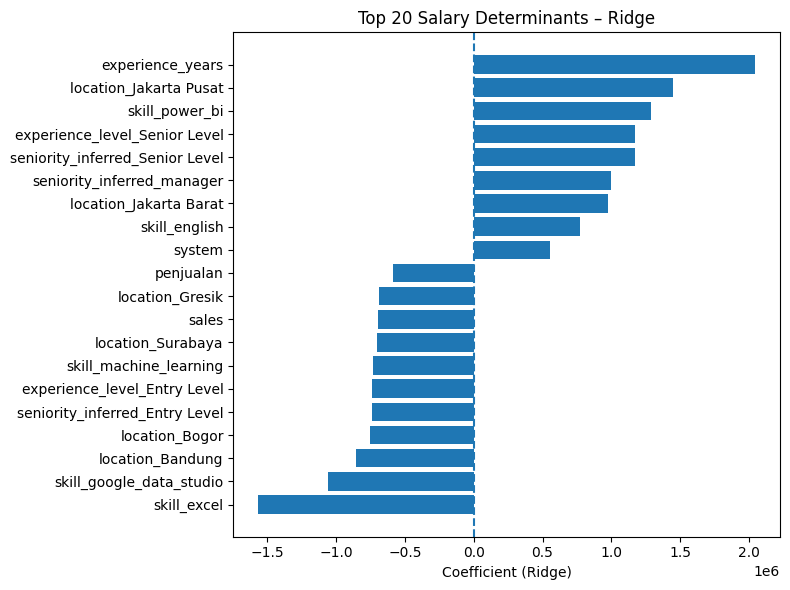


Top 20 salary determinants – Lasso:
                    feature          coef      abs_coef
11                   access -2.120978e+08  2.120978e+08
79           analysis tools -5.981866e+07  5.981866e+07
81         analysis working  5.892555e+07  5.892555e+07
5         ability translate  4.978040e+07  4.978040e+07
122            architecture  4.490134e+07  4.490134e+07
86      analyst description  4.386415e+07  4.386415e+07
212                   biaya  4.181891e+07  4.181891e+07
40                      age -4.087336e+07  4.087336e+07
4           ability present  3.892739e+07  3.892739e+07
158               baik baik -3.888255e+07  3.888255e+07
26                      ada -3.817570e+07  3.817570e+07
72        analysis business  3.772695e+07  3.772695e+07
53              align goals -3.754657e+07  3.754657e+07
2            ability gather  3.657792e+07  3.657792e+07
30                    adobe  3.652333e+07  3.652333e+07
48                  akurasi -3.612704e+07  3.612704e+07
189        

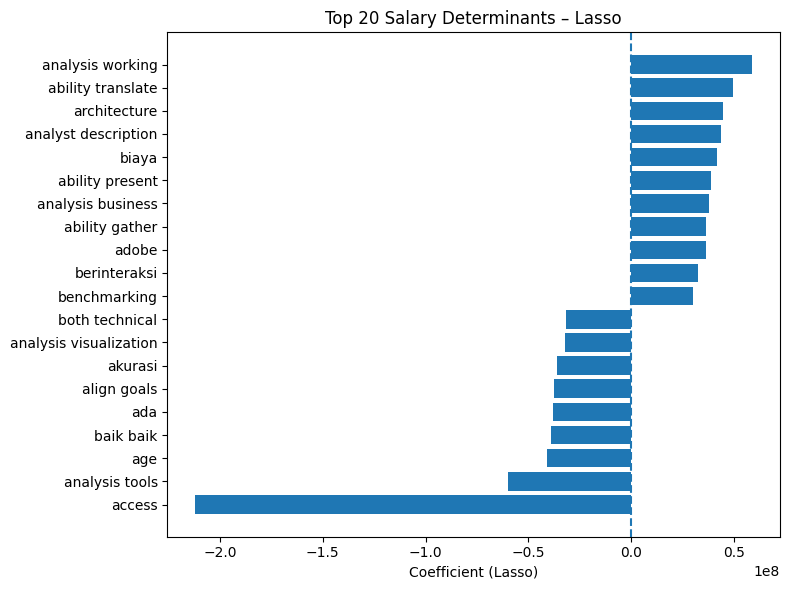

Saved coefficients to:
 - /content/determinants_coefficients_ridge.csv
 - /content/determinants_coefficients_lasso.csv


In [ ]:
# ============================================================
# 17. SALARY DETERMINANTS – COEFFICIENTS (RIDGE & LASSO)
# ============================================================
# RIDGE
ridge_prep = ridge_model.named_steps["prep"]
ridge_est  = ridge_model.named_steps["mdl"]

txt_names = ridge_prep.named_transformers_["txt"].get_feature_names_out()
num_names = np.array([c for c in num_feats if c in X_train.columns])
cat_names = ridge_prep.named_transformers_["cat"].get_feature_names_out(
    [c for c in cat_feats if c in X_train.columns]
)

ridge_feature_names = np.concatenate([txt_names, num_names, cat_names])
ridge_coefs = ridge_est.coef_.ravel()

ridge_coef_df = pd.DataFrame({
    "feature": ridge_feature_names,
    "coef": ridge_coefs
})
ridge_coef_df["abs_coef"] = ridge_coef_df["coef"].abs()
ridge_coef_df = ridge_coef_df.sort_values("abs_coef", ascending=False)

print("\nTop 20 salary determinants – Ridge:")
print(ridge_coef_df.head(20))

top20_ridge = ridge_coef_df.head(20).sort_values("coef")

plt.figure(figsize=(8, 6))
plt.barh(top20_ridge["feature"], top20_ridge["coef"])
plt.axvline(0, linestyle="--")
plt.xlabel("Coefficient (Ridge)")
plt.title("Top 20 Salary Determinants – Ridge")
plt.tight_layout()
plt.show()

# LASSO
lasso_prep = lasso_model.named_steps["prep"]
lasso_est  = lasso_model.named_steps["mdl"]

txt_names_l = lasso_prep.named_transformers_["txt"].get_feature_names_out()
num_names_l = np.array([c for c in num_feats if c in X_train.columns])
cat_names_l = lasso_prep.named_transformers_["cat"].get_feature_names_out(
    [c for c in cat_feats if c in X_train.columns]
)

lasso_feature_names = np.concatenate([txt_names_l, num_names_l, cat_names_l])
lasso_coefs = lasso_est.coef_.ravel()

lasso_coef_df = pd.DataFrame({
    "feature": lasso_feature_names,
    "coef": lasso_coefs
})
lasso_coef_df["abs_coef"] = lasso_coef_df["coef"].abs()
lasso_coef_df = lasso_coef_df.sort_values("abs_coef", ascending=False)

print("\nTop 20 salary determinants – Lasso:")
print(lasso_coef_df.head(20))

top20_lasso = lasso_coef_df.head(20).sort_values("coef")

plt.figure(figsize=(8, 6))
plt.barh(top20_lasso["feature"], top20_lasso["coef"])
plt.axvline(0, linestyle="--")
plt.xlabel("Coefficient (Lasso)")
plt.title("Top 20 Salary Determinants – Lasso")
plt.tight_layout()
plt.show()

# Simpan koefisien untuk lampiran paper
ridge_coef_path = "/content/determinants_coefficients_ridge.csv"
lasso_coef_path = "/content/determinants_coefficients_lasso.csv"
ridge_coef_df.to_csv(ridge_coef_path, index=False, encoding="utf-8-sig")
lasso_coef_df.to_csv(lasso_coef_path, index=False, encoding="utf-8-sig")
print("Saved coefficients to:")
print(" -", ridge_coef_path)
print(" -", lasso_coef_path)
